Precisión alcanzada: 99.13%


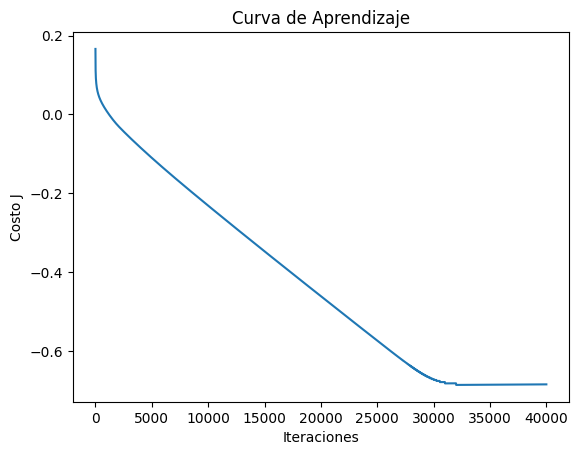

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot

data = pd.read_csv('procesados/6_credit_approval.csv', header=None)

# Reemplazamos cualquier valor no numérico extraño por 0 y convertimos todo a número
# Esto asegura que X e y sean arreglos de floats, no de objetos/strings
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)

X = data.iloc[:, :-1].values.astype(float)
y = data.iloc[:, -1].values.astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500))) # clip evita desbordamiento matemático

def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    # Añadimos un valor minúsculo (1e-15) para evitar log(0)
    J = (1 / m) * np.sum(-y * np.log(h + 1e-15) - (1 - y) * np.log(1 - h + 1e-15))
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

m, n = X.shape
X = np.concatenate([np.ones((m, 1)), X], axis=1)

initial_theta = np.zeros(n + 1)
iterations = 40000
alpha = 0.0001

theta_final, J_history = descensoGradiente(initial_theta, X, y, alpha, iterations)

# RESULTADOS
p = (sigmoid(X.dot(theta_final.T)) >= 0.5).astype(int)
accuracy = np.mean(p == y) * 100

print(f"Precisión alcanzada: {accuracy:.2f}%")

# Gráfico de convergencia
pyplot.plot(np.arange(len(J_history)), J_history)
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Curva de Aprendizaje')
pyplot.show()